# 02 — Exploratory Data Analysis

The data audit told us what quality issues exist and where proxy risks lie. This notebook asks the next question: what patterns 
actually drive income prediction — and do those patterns look different across demographic groups?

Each visualization is here to answer a specific question, not to describe the data mechanically.

First, imports and configuration and data loading.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

In [2]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [3]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

train = pd.read_csv(
    "../data/raw/adult.data",
    names=columns,
    skipinitialspace=True
)

In [4]:
# replace ? with NaN for easier handling
train.replace("?", np.nan, inplace=True)

print(f"Train shape: {train.shape}")

Train shape: (32561, 15)


## 1. Who earns above $50K? — Income Distribution by Age
**Question:** Is there a clear age pattern in high earners, and does it differ by sex?

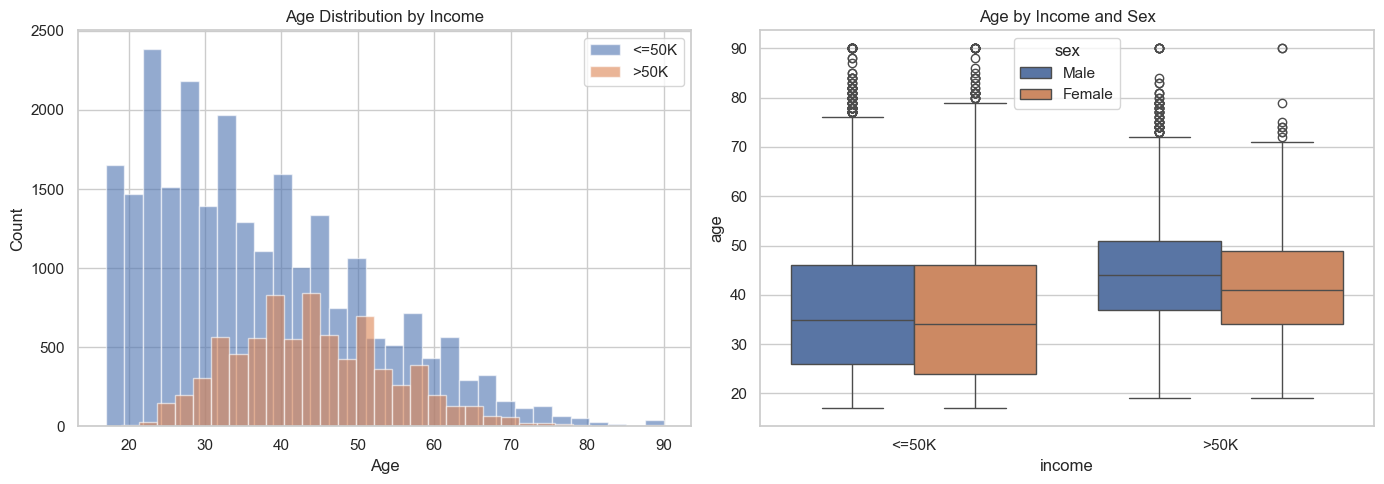

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# age distribution by income
for income, group in train.groupby("income"):
    axes[0].hist(group["age"], bins=30, alpha=0.6, label=income)
axes[0].set_title("Age Distribution by Income")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")
axes[0].legend()

# age distribution by income and sex
sns.boxplot(
    data=train,
    x="income",
    y="age",
    hue="sex",
    ax=axes[1]
)
axes[1].set_title("Age by Income and Sex")

plt.tight_layout()
plt.savefig("../reports/figures/age_by_income.png", dpi=150)
plt.show()

### Observations 1 — Age and Income

- **High earners (>50K)** follow a near-normal distribution centered around age 40 — peak earning years align with mid-career seniority 
  and experience accumulation.
- **Low earners (<=50K)** peak at younger ages and decline gradually — reflecting entry-level workers, students, and early career profiles. 
  Almost no one under 25 earns above $50K in this dataset.
- **Age is a strong predictor of income** — but the relationship is not linear. It rises through mid-career and flattens or declines at older ages.

**Sex dimension adds a fairness signal:**
- The gap between male and female median age is larger in the high-income group than the low-income group — women who earn 
  above $50K tend to be older than men who do, suggesting women need more years of experience to reach the same income threshold.
- Male age range is wider in the high-income group — more male outliers at both ends.
- This is not just a demographic observation — it is a modeling risk. Age interacts with sex in predicting income, meaning a model can use age as a partial proxy for sex.

## 2. Does education level translate to income equally for everyone?
**Question:** Is the education-to-income relationship consistent across sex and race — or does it differ by group?

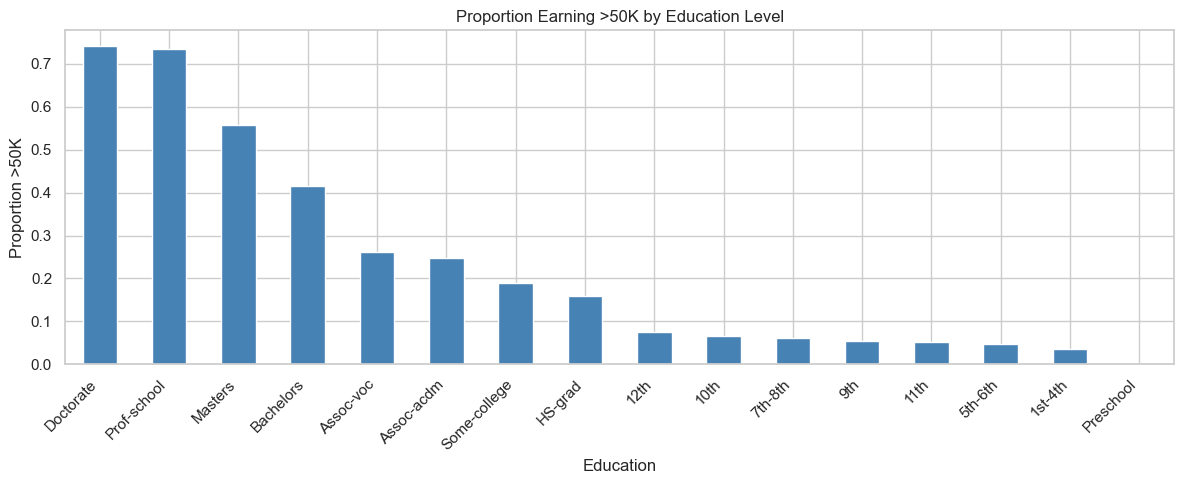

education
Doctorate       0.741
Prof-school     0.734
Masters         0.557
Bachelors       0.415
Assoc-voc       0.261
Assoc-acdm      0.248
Some-college    0.190
HS-grad         0.160
12th            0.076
10th            0.066
7th-8th         0.062
9th             0.053
11th            0.051
5th-6th         0.048
1st-4th         0.036
Preschool       0.000
Name: income, dtype: float64


In [6]:
# income rate by education level
edu_income = train.groupby("education")["income"].apply(
    lambda x: (x == ">50K").mean()
).sort_values(ascending=False).round(3)

plt.figure(figsize=(12, 5))
edu_income.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Proportion Earning >50K by Education Level")
plt.xlabel("Education")
plt.ylabel("Proportion >50K")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/income_by_education.png", dpi=150)
plt.show()

print(edu_income)

### Observations 2 — Education and Income

**The relationship is strong but not gradual — there are sharp thresholds:**

- **Doctorate (74.1%) and Prof-school (73.4%)** are nearly identical and sit far above everything else — terminal degrees have a disproportionate income premium
- **Masters (55.7%) to Bachelors (41.5%)** — a meaningful jump, but both are above the dataset average of ~25%
- **Sharp cliff between Bachelors (41.5%) and Assoc-voc (26.1%)** - a 4-year degree creates a significant income threshold, not a gradual slope
- **HS-grad to Some-college is nearly flat** (16% vs 19%) — some college without a degree adds almost no income premium
- **Below HS-grad, income rates collapse to near zero** — 5th-6th grade (4.8%), Preschool (0%)

**Why this matters for modeling and fairness:**

Education is one of the strongest single predictors of income in this dataset. But recall from the data audit — higher education credentials are not equally distributed across racial groups. Asian-Pac-Islander has 28% Bachelors vs Black at 11% and Amer-Indian-Eskimo at 6%.

This means education will be a high-importance feature in every model we build — and that importance will silently carry racial 
disparities into every prediction. A model that learns "Bachelors → likely >50K" is also partially learning "Asian or White → likely >50K."

## 3. Does the same occupation pay equally across sex?
**Question:** Within the same occupation, is the income rate different for males and females?

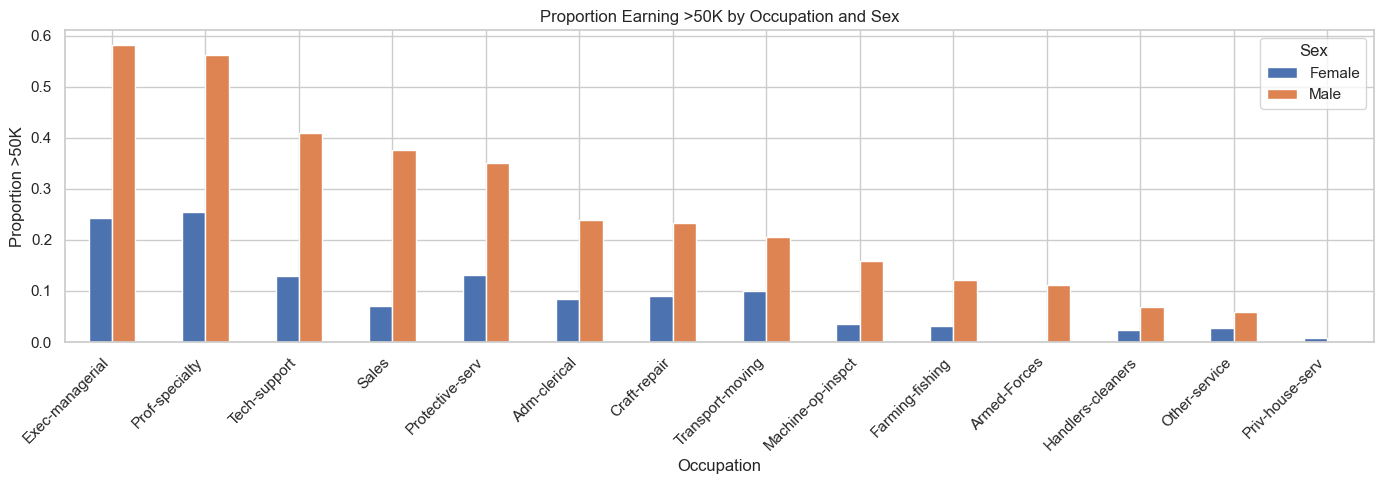

sex                Female   Male
occupation                      
Exec-managerial     0.242  0.581
Prof-specialty      0.254  0.562
Tech-support        0.129  0.410
Sales               0.070  0.375
Protective-serv     0.132  0.351
Adm-clerical        0.084  0.239
Craft-repair        0.090  0.234
Transport-moving    0.100  0.206
Machine-op-inspct   0.036  0.158
Farming-fishing     0.031  0.122
Armed-Forces          NaN  0.111
Handlers-cleaners   0.024  0.068
Other-service       0.028  0.058
Priv-house-serv     0.007  0.000


In [7]:
# income rate by occupation and sex
occ_sex_income = train.groupby(["occupation", "sex"])["income"].apply(
    lambda x: (x == ">50K").mean()
).round(3).unstack()

occ_sex_income = occ_sex_income.sort_values("Male", ascending=False)

occ_sex_income.plot(kind="bar", figsize=(14, 5), edgecolor="white")
plt.title("Proportion Earning >50K by Occupation and Sex")
plt.xlabel("Occupation")
plt.ylabel("Proportion >50K")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sex")
plt.tight_layout()
plt.savefig("../reports/figures/income_by_occupation_sex.png", dpi=150)
plt.show()

print(occ_sex_income)

### Observations 3 — Income Gap Within Occupation by Sex

Even within the same occupation, males consistently out-earn females.
This is not a composition effect — it is a within-group disparity.

**Largest gaps:**
- **Exec-managerial:** Male 58.1% vs Female 24.2% — a 33.9 point gap. The highest-paying occupation category shows the largest disparity.
- **Prof-specialty:** Male 56.2% vs Female 25.4% — a 30.8 point gap.
- **Tech-support:** Male 41.0% vs Female 12.9% — a 28.1 point gap.

**Notable observations:**
- No occupation has female income rate exceeding male income rate
- `Priv-house-serv` is the single exception — female 0.7% vs male 0.0% but this is a near-zero category dominated by females with very few male instances, making the comparison unreliable
- The gap is largest in high-income occupations and smallest in low-income ones — meaning the ceiling is lower for women, not just the floor

**Modeling implication:**
A model trained on this data will learn that occupation predicts income differently depending on sex — because it does, in this data. 
Without fairness constraints, the model will reproduce and potentially amplify this gap. This will be quantified precisely in the fairness analysis notebook.

## 4. Capital gain — signal or noise?
**Question:** Is capital-gain actually informative, or is it dominated by zeros and outliers?

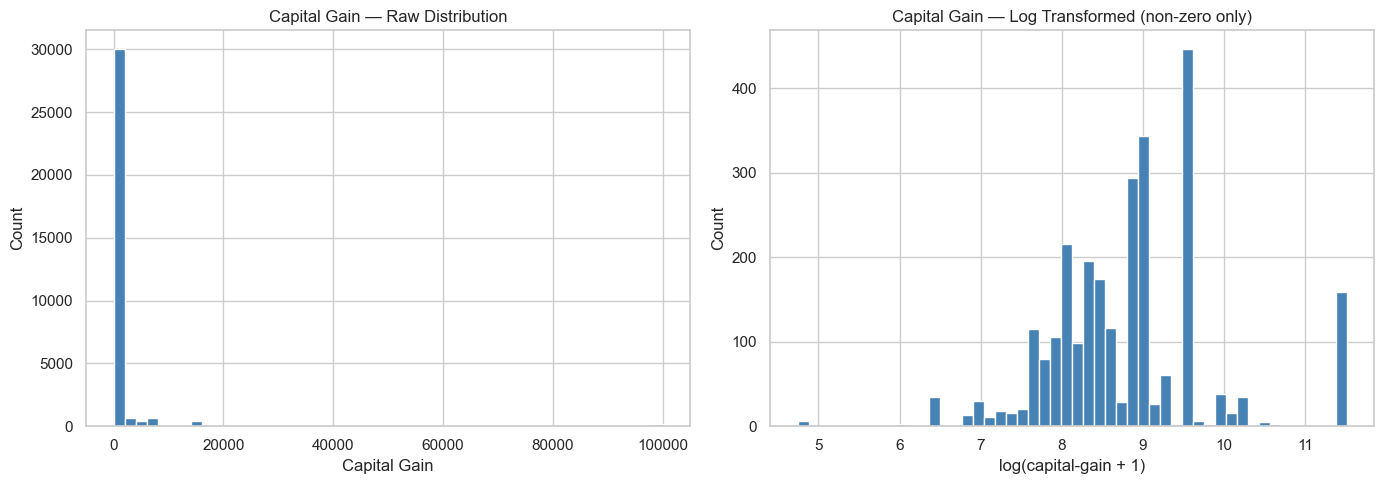

Rows with zero capital-gain: 29849 (91.7%)
Rows with capital-gain = 99999: 159


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw distribution
axes[0].hist(train["capital-gain"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Capital Gain — Raw Distribution")
axes[0].set_xlabel("Capital Gain")
axes[0].set_ylabel("Count")

# log transformed -- only non-zero values
nonzero = train[train["capital-gain"] > 0]["capital-gain"]
axes[1].hist(np.log1p(nonzero), bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("Capital Gain — Log Transformed (non-zero only)")
axes[1].set_xlabel("log(capital-gain + 1)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../reports/figures/capital_gain_distribution.png", dpi=150)
plt.show()

print(f"Rows with zero capital-gain: {(train['capital-gain'] == 0).sum()} "
      f"({(train['capital-gain'] == 0).mean():.1%})")
print(f"Rows with capital-gain = 99999: {(train['capital-gain'] == 99999).sum()}")

### Observations 4 — Capital Gain Distribution

- **91.7% of rows have zero capital gain** — this is not a normal continuous variable. It is effectively a two-part distribution: a massive zero mass and a separate non-zero distribution.
- **159 rows have capital-gain = 99,999** — this is almost certainly a cap value, not a real observation. No natural distribution 
  produces this kind of spike at a round number ceiling.
- **Log transformation reveals structure** in the non-zero values — there are actually two clusters in the non-zero distribution, 
  suggesting different types of capital income.

**Modeling implication:**
Treating capital-gain as a standard continuous feature is wrong. 
Three options worth considering:
1. Binary flag — did the person report any capital gain? (yes/no)
2. Log transformation on non-zero values + binary flag combined
3. Binning into meaningful brackets: zero, low, medium, capped

The 99,999 cap values should be treated separately — they likely represent high earners whose actual gains exceed the recording threshold, making them a signal in themselves.

Same pattern applies to `capital-loss` — will be handled identically.

## 5. Hours per week — do high earners just work more?
**Question:** Is income driven by hours worked, or does the relationship differ by sex?

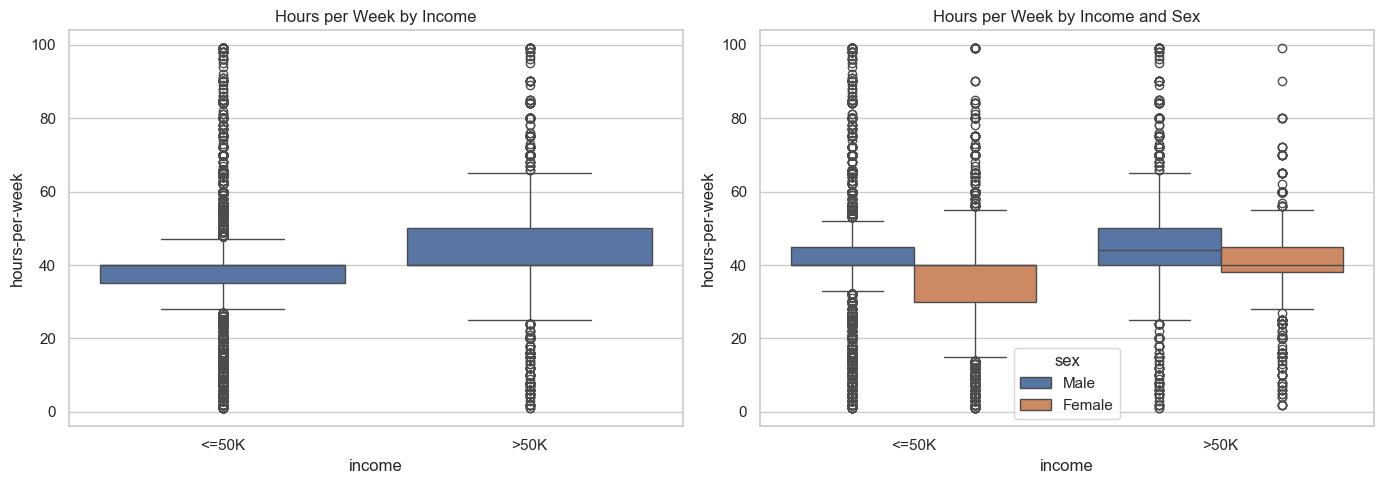

income  sex   
<=50K   Female    40.0
        Male      40.0
>50K    Female    40.0
        Male      44.0
Name: hours-per-week, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# hours per week by income
sns.boxplot(
    data=train,
    x="income",
    y="hours-per-week",
    ax=axes[0]
)
axes[0].set_title("Hours per Week by Income")

# hours per week by income and sex
sns.boxplot(
    data=train,
    x="income",
    y="hours-per-week",
    hue="sex",
    ax=axes[1]
)
axes[1].set_title("Hours per Week by Income and Sex")

plt.tight_layout()
plt.savefig("../reports/figures/hours_by_income_sex.png", dpi=150)
plt.show()

print(train.groupby(["income", "sex"])["hours-per-week"].median())

### Observations 5 — Hours per Week and Income

**Median hours:**
- <=50K: both male and female median is 40 — standard full-time work
- >50K Female: median is still 40 — high-earning women work standard hours
- >50K Male: median jumps to 44 — high-earning men work more on average

**But the distribution tells a richer story:**
- The IQR for high earners is wider and shifted upward — more variance in hours among high earners, not just a simple "work more, earn more"
- Low-earning females have a noticeably lower and tighter IQR than low-earning males — more concentrated around 40, less part-time work 
  represented, or less overtime
- Both groups have outliers reaching 98-99 hours — likely the same cap artifact we saw in capital-gain

**The critical finding:**
High-earning women work the same median hours as low-earning women — 40 hours. High-earning men work more. This suggests that for women, 
working longer hours does not translate to the same income premium it does for men. The path to high income looks structurally different 
by sex — it is not simply a matter of hours worked.

**Modeling implication:**
`hours-per-week` interacts with `sex` in predicting income. A model that ignores this interaction will systematically misrepresent 
how work hours relate to income for female employees.

## 6. Race and Income — representation and outcome
**Question:** How does income rate vary by race, and is the 
sample size large enough for meaningful subgroup analysis?

                    count  pct_high_income
race                                      
Asian-Pac-Islander   1039            0.266
White               27816            0.256
Black                3124            0.124
Amer-Indian-Eskimo    311            0.116
Other                 271            0.092


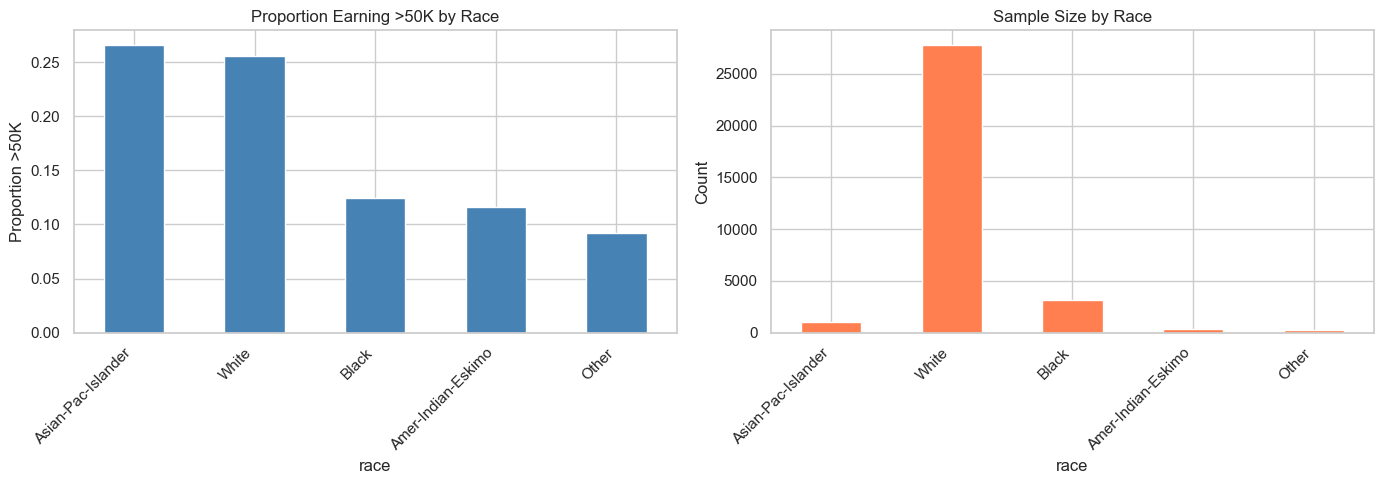

In [11]:
race_income = train.groupby("race").agg(
    count=("income", "count"),
    pct_high_income=("income", lambda x: (x == ">50K").mean())
).round(3).sort_values("pct_high_income", ascending=False)

print(race_income)

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

race_income["pct_high_income"].plot(
    kind="bar", ax=axes[0],
    color="steelblue", edgecolor="white"
)
axes[0].set_title("Proportion Earning >50K by Race")
axes[0].set_ylabel("Proportion >50K")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

race_income["count"].plot(
    kind="bar", ax=axes[1],
    color="coral", edgecolor="white"
)
axes[1].set_title("Sample Size by Race")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../reports/figures/income_by_race.png", dpi=150)
plt.show()

### Observations 6 — Race, Income, and Representation

**Income rate by race:**
- Asian-Pac-Islander (26.6%) and White (25.6%) are nearly identical and sit well above the others
- Black (12.4%) and Amer-Indian-Eskimo (11.6%) are less than half the rate of White — not a marginal difference, a structural one
- Other (9.2%) is the lowest — but this category is itself problematic as a grouping (see below)

**The sample size problem is as important as the outcome:**
- White: 27,816 instances — statistically robust for any analysis
- Black: 3,124 — adequate for group-level analysis but limited for intersectional cuts (e.g. Black + female + specific occupation)
- Asian-Pac-Islander: 1,039 — borderline for reliable subgroup metrics
- Amer-Indian-Eskimo: 311 — too small for statistically reliable fairness metrics. Findings for this group should be interpreted with caution.
- Other: 271 — the smallest group and also the least meaningful categorically. Grouping diverse backgrounds into "Other" is itself a data quality issue that limits any analysis.

**Why this matters for fairness analysis:**
Fairness metrics computed on 271 or 311 instances have wide confidence intervals — a measured disparity could be real or could be sampling 
noise. We will report confidence intervals alongside fairness metrics for small groups rather than treating point estimates as facts.

This is a limitation of the dataset, not of the analysis. 
Acknowledging it is part of doing the work honestly.

## 7. Education vs Education-num — Redundancy Check
**Question:** Are education and education-num truly redundant, or does one carry information the other doesn't?

In [12]:
# check the mapping between education and education-num
edu_mapping = train.groupby("education")["education-num"].agg(["min", "max", "nunique"])
print(edu_mapping.sort_values("min"))

              min  max  nunique
education                      
Preschool       1    1        1
1st-4th         2    2        1
5th-6th         3    3        1
7th-8th         4    4        1
9th             5    5        1
10th            6    6        1
11th            7    7        1
12th            8    8        1
HS-grad         9    9        1
Some-college   10   10        1
Assoc-voc      11   11        1
Assoc-acdm     12   12        1
Bachelors      13   13        1
Masters        14   14        1
Prof-school    15   15        1
Doctorate      16   16        1


### Observation 7 — Perfect Redundancy Confirmed

Every `education` category maps to exactly one unique `education-num` 
value with zero overlap. Min equals max for all 16 levels — there is 
no instance where the same education label has different numeric values 
or vice versa.

This is a 1:1 deterministic mapping — knowing one column tells you 
the other with 100% certainty. Keeping both would introduce 
redundant information into the feature space without adding 
any predictive signal.

**Decision: drop `education-num` before modeling.**

We keep `education` as the categorical label — it is more 
interpretable and directly meaningful. The numeric encoding 
will be handled by our preprocessing pipeline during 
feature engineering.

________________________________________

## 8. EDA Summary — What We Now Know

### Key Findings

**Strongest predictors of income:**
- **Education** — sharpest single predictor. Clear threshold effect at Bachelors level. Doctorate and Prof-school are in a category of their own at ~74% high-income rate.
- **Occupation** — strong predictor, but heavily confounded with sex and race. Exec-managerial and Prof-specialty dominate.
- **Age** — non-linear relationship. High earners concentrate between 35-55. Almost no high earners under 27.
- **Hours-per-week** — predictive for males, much weaker signal for females. Interaction effect with sex is significant.
- **Capital-gain** — highly informative when non-zero, but 91.7% of values are zero. Requires binary flag + log transformation, not standard continuous treatment.

**Fairness risks identified:**
- Within the same occupation, male income rates are consistently 2-3x higher than female rates. This is not a composition effect.
- High-earning women work the same median hours as low-earning women — the hours-to-income pathway is structurally different 
  by sex.
- Education and occupation are strong proxies for race — removing protected attributes from the feature set does not remove bias.
- Small sample sizes for Amer-Indian-Eskimo (311) and Other (271) limit statistical reliability of fairness metrics for these groups.

**Preprocessing decisions the data demands:**
- Replace `?` with `Unknown` category — do not impute
- Drop `fnlwgt` — census weight, not a predictive feature
- Drop `education-num` — redundant with `education`
- Apply log transformation to non-zero `capital-gain` 
  and `capital-loss`, add binary flags for both
- Bin `hours-per-week` into meaningful brackets or keep continuous 
  with interaction term with `sex`
- Cap outliers at 99th percentile for continuous features

**What EDA does not tell us:**
Feature importance in isolation does not equal feature importance in a model — interactions, correlations, and regularization all 
shift the picture. The modeling notebook will validate these intuitions against actual model behavior.